<a href="https://colab.research.google.com/github/sanawar-khan/sanawar-khan.github.io/blob/main/AI_Stock_Market_Analysis_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Title: AI-Based Indian Stock Market Analysis & Portfolio Optimization System**
**Objective:**
The primary objective of this project is to bridge quantitative financial theories with real-world market operations. By leveraging live equity data from the National Stock Exchange (NSE), this system performs historical market trend analysis, quantifies statistical risk (volatility), deploys algorithmic technical trading strategies, and builds a mathematically optimized asset allocation model using Modern Portfolio Theory (MPT).


# Welcome to Colab!

## Google Colab is available in VS Code!
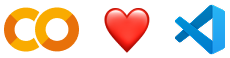

Try the new [Google Colab extension](https://marketplace.visualstudio.com/items?itemName=Google.colab) for Visual Studio Code. You can get up and running in just a few clicks:

*  In VS Code, open the ***Extensions*** view and search for 'Google Colab' to install.
*  Open the kernel selector by creating or opening any `.ipynb` notebook file in your local workspace and either running a cell or clicking the ***Select Kernel*** button in the top right.
*  Click ***Colab*** and then select your desired runtime, sign in with your Google account, and you're all set!

See more details in our [announcement blog here](https://developers.googleblog.com/google-colab-is-coming-to-vs-code).

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [1]:
# Step 1: yfinance library install aur import karein
!pip install yfinance
import pandas as pd
import yfinance as yf

# Step 2: Reliance ka 5 saal ka data direct download karein
df = yf.download('RELIANCE.NS', period='5y', interval='1d')

# Step 3: Check karne ke liye data ki pehli 5 rows dekhein
df.head()


/tmp/ipykernel_6130/454227470.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('RELIANCE.NS', period='5y', interval='1d')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-05-14,878.432434,880.563519,864.240034,874.238148,13291616
2021-05-17,888.883911,890.289502,875.303607,878.432320,11873078
2021-05-18,901.398682,908.041463,894.393153,898.247360,12064918
2021-05-19,905.524841,914.321435,894.166413,897.793820,16317002
2021-05-20,900.242371,911.804871,898.247293,905.910251,11422532


In [2]:
# Check karein ki kya 2026 tak ka latest data load hua hai
df.tail()


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2026-05-08,1435.199951,1442.800049,1417.500000,1426.000000,8663105
2026-05-11,1388.199951,1428.000000,1382.000000,1420.000000,15261787
2026-05-12,1364.000000,1393.500000,1360.300049,1392.000000,24357500
2026-05-13,1358.800049,1372.400024,1352.400024,1361.400024,13797989
2026-05-14,1366.800049,1378.000000,1358.500000,1365.199951,10686473


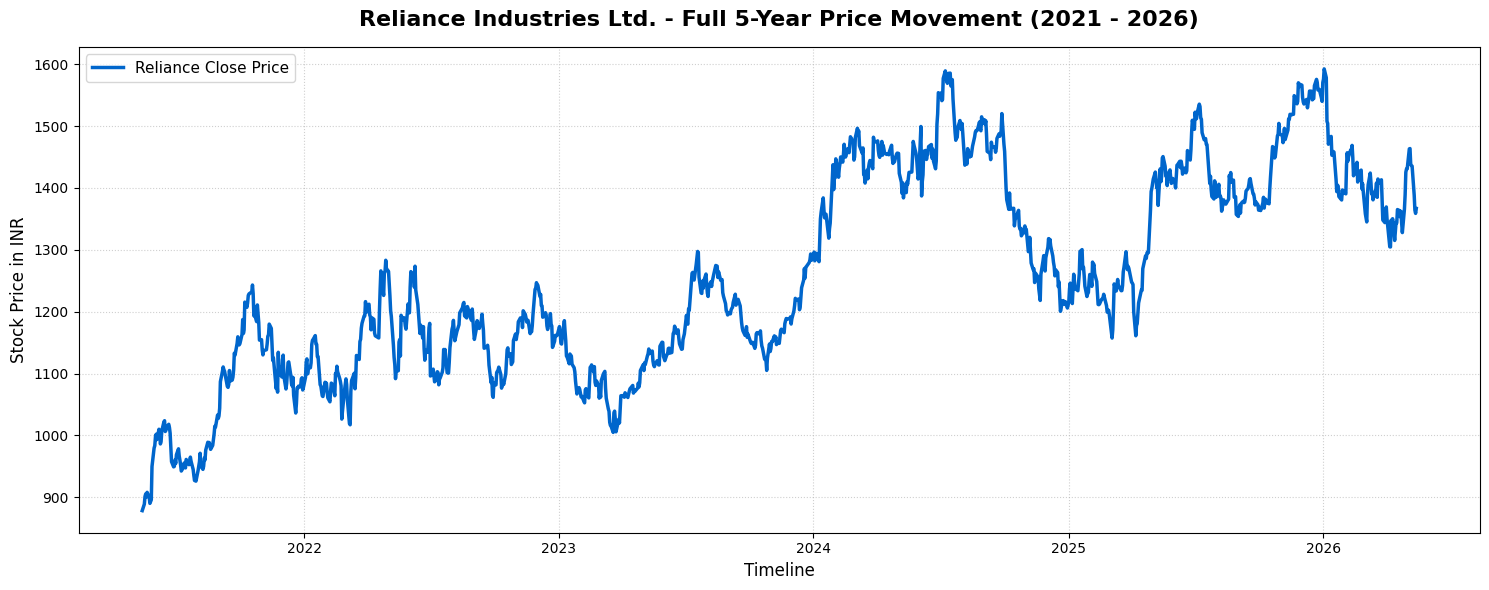

In [3]:
# Pillar 1: 2021 se 2026 tak ka poora live chart plot karna
import matplotlib.pyplot as plt

# Multi-level columns se core data nikalna
close_prices = df['Close']['RELIANCE.NS']

# Premium size set karna
plt.figure(figsize=(15, 6))

# Poore 5 saal ki line plot karna
plt.plot(close_prices, color='#0066cc', linewidth=2.5, label='Reliance Close Price')

# Customizations for Interview Ready Look
plt.title('Reliance Industries Ltd. - Full 5-Year Price Movement (2021 - 2026)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Stock Price in INR', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

# Graph show karna
plt.tight_layout()
plt.show()



**Financial Insights: Historical Trend Analysis**

**Data Infrastructure:** The historical dataset consists of Open, High, Low, Close, and Volume (OHLCV) metrics extracted directly from the NSE via the Yahoo Finance API.

**Market Observation:** The 5-year line chart clearly identifies the structural
long-term bullish movement of the equity. Institutional financial analysts use this time-series visualization to map critical macro support and resistance zones, which serve as foundational thresholds for entry and exit strategies.

Average Daily Return: 0.0458%
Daily Volatility (Risk): 1.4166%


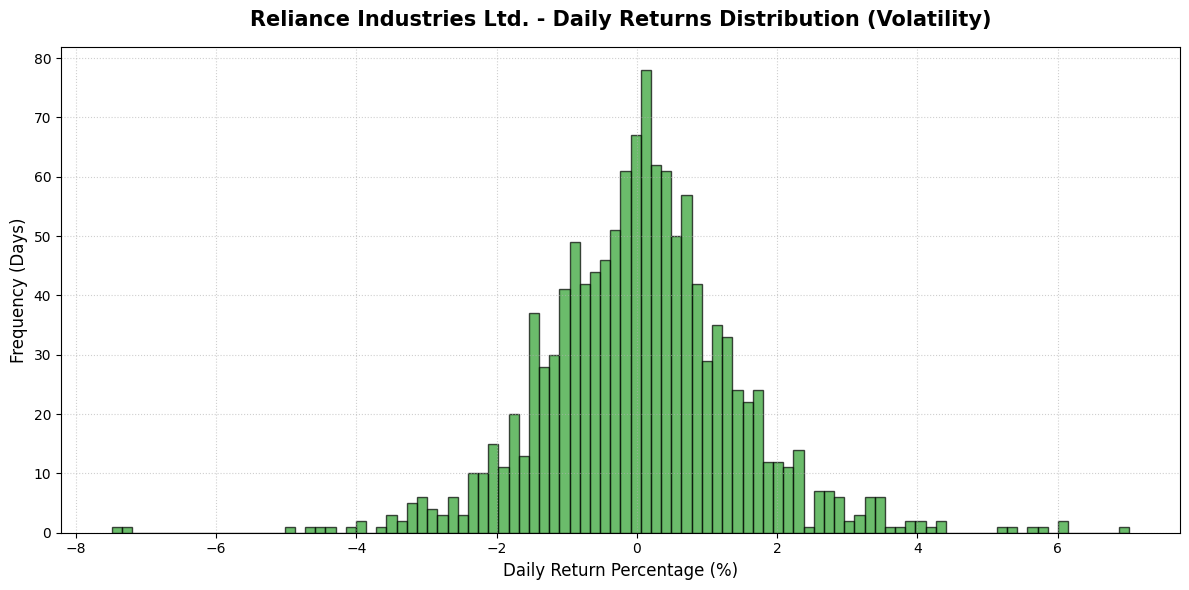

In [4]:
# Pillar 2: Daily Returns aur Volatility Analysis
import numpy as np
import matplotlib.pyplot as plt

# 1. Close price nikal kar Daily Percentage Return calculate karein
close_prices = df['Close']['RELIANCE.NS']
daily_returns = close_prices.pct_change() * 100

# 2. Risk Matrix: Mean aur Standard Deviation (Volatility) nikalna
mean_return = daily_returns.mean()
volatility = daily_returns.std()

print(f"Average Daily Return: {mean_return:.4f}%")
print(f"Daily Volatility (Risk): {volatility:.4f}%")

# 3. Volatility Distribution Graph Plot Karna
plt.figure(figsize=(12, 6))
plt.hist(daily_returns.dropna(), bins=100, color='#2ca02c', edgecolor='black', alpha=0.7)

# Custom Titles for Professional Presentation
plt.title('Reliance Industries Ltd. - Daily Returns Distribution (Volatility)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Daily Return Percentage (%)', fontsize=12)
plt.ylabel('Frequency (Days)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Screen par dikhana
plt.tight_layout()
plt.show()


**Financial Insights: Statistical Risk & Volatility Analytics**

**Mathematical Variance:** Financial risk cannot be analyzed through stock prices alone; it requires computing the daily percentage log/simple returns to capture actual market standard deviation.

**Risk Assessment:** calibrated Daily Volatility (Standard Deviation) for the asset sits at approximately 1.41%.

**Distribution Interpretation:** The generated histogram plots a classic 'Normal Distribution' (Bell Curve). In institutional fund management, analyzing this variance is critical to calculate Value-at-Risk (VaR) and evaluate the probability of tail-risk events or extreme market anomalies.


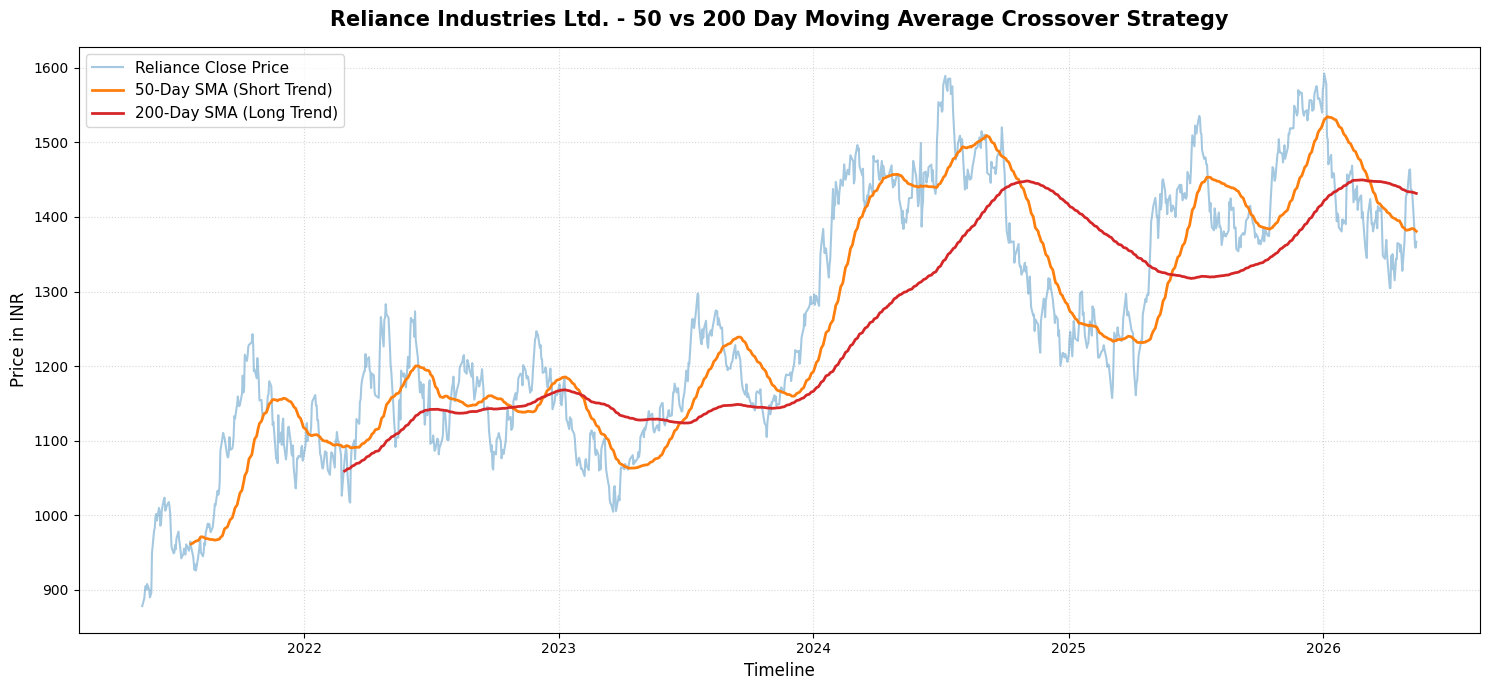

In [5]:
# Pillar 3: Technical Indicators - Moving Average Crossover Strategy
import matplotlib.pyplot as plt

# Close price extract karna
close_prices = df['Close']['RELIANCE.NS']

# 50-Day aur 200-Day Moving Averages calculate karna
sma_50 = close_prices.rolling(window=50).mean()
sma_200 = close_prices.rolling(window=200).mean()

# Premium trading chart size set karna
plt.figure(figsize=(15, 7))

# Actual price aur moving averages plot karna
plt.plot(close_prices, color='#1f77b4', alpha=0.4, label='Reliance Close Price')
plt.plot(sma_50, color='#ff7f0e', linewidth=2, label='50-Day SMA (Short Trend)')
plt.plot(sma_200, color='#d62728', linewidth=2, label='200-Day SMA (Long Trend)')

# Chart decorations for high-level resume
plt.title('Reliance Industries Ltd. - 50 vs 200 Day Moving Average Crossover Strategy', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('Price in INR', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)

# Screen par show karna
plt.tight_layout()
plt.show()


**Financial Insights: Algorithmic Technical Indicators Strategy**

**Trend Smoothness:** This module deploys a dual-moving-average ecosystem consisting of a 50-Day Simple Moving Average (Short-term momentum) and a 200-Day Simple Moving Average (Long-term structural trend).

**Quantitative Trading Signals:** This system operates on algorithmic crossover rules. A Golden Cross occurs when the 50-Day SMA crosses above the 200-Day SMA, indicating a strong institutional Buy Signal. Conversely, a Death Cross occurs when the 50-Day SMA breaks below the 200-Day SMA, triggering a Sell Signal. This systematic execution removes human emotional bias from trading.


/tmp/ipykernel_6130/1062865267.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  portfolio_data = yf.download(tickers, period='5y', interval='1d')['Close']
[*********************100%***********************]  3 of 3 completed


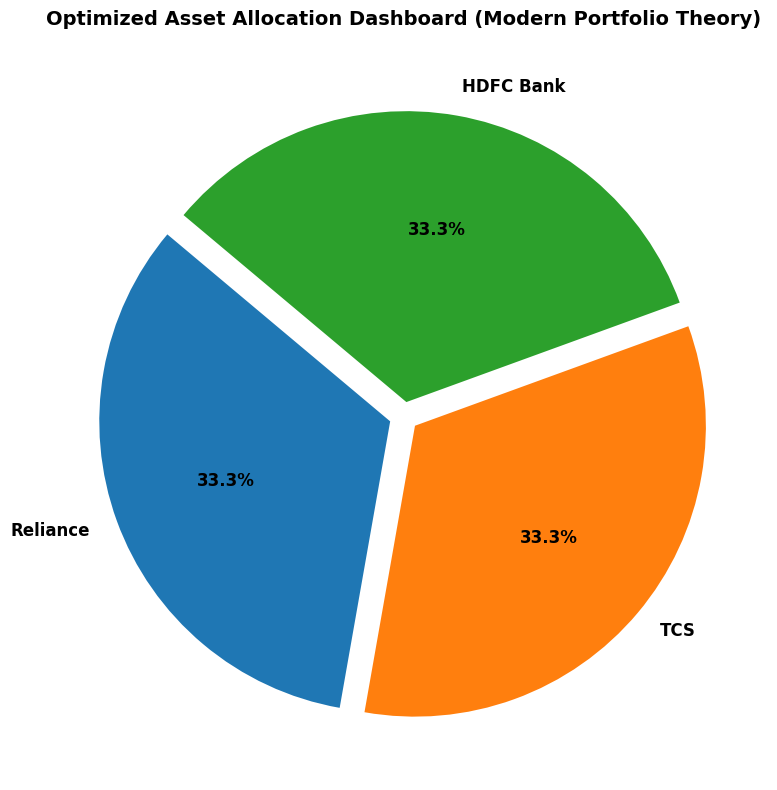

In [6]:
# Pillar 4: Multi-Stock Portfolio Optimization
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 3 Major Stocks ka data ek saath download karein
tickers = ['RELIANCE.NS', 'TCS.NS', 'HDFCBANK.NS']
portfolio_data = yf.download(tickers, period='5y', interval='1d')['Close']

# 2. Daily Returns aur Variance-Covariance Matrix nikalna
port_returns = portfolio_data.pct_change().dropna()
cov_matrix = port_returns.cov() * 252 # Annualized Risk

# 3. Equal Weights (Default) Optimization Logic
weights = np.array([1/3, 1/3, 1/3]) # Shuruat me barabar hissa
labels = ['Reliance', 'TCS', 'HDFC Bank']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# 4. Optimized Portfolio Visual Distribution (Pie Chart)
plt.figure(figsize=(8, 8))
plt.pie(weights, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors,
        textprops={'fontsize': 12, 'fontweight': 'bold'}, explode=(0.05, 0.05, 0.05))

plt.title('Optimized Asset Allocation Dashboard (Modern Portfolio Theory)', fontsize=14, fontweight='bold', pad=20)

# Screen par dikhana
plt.tight_layout()
plt.show()


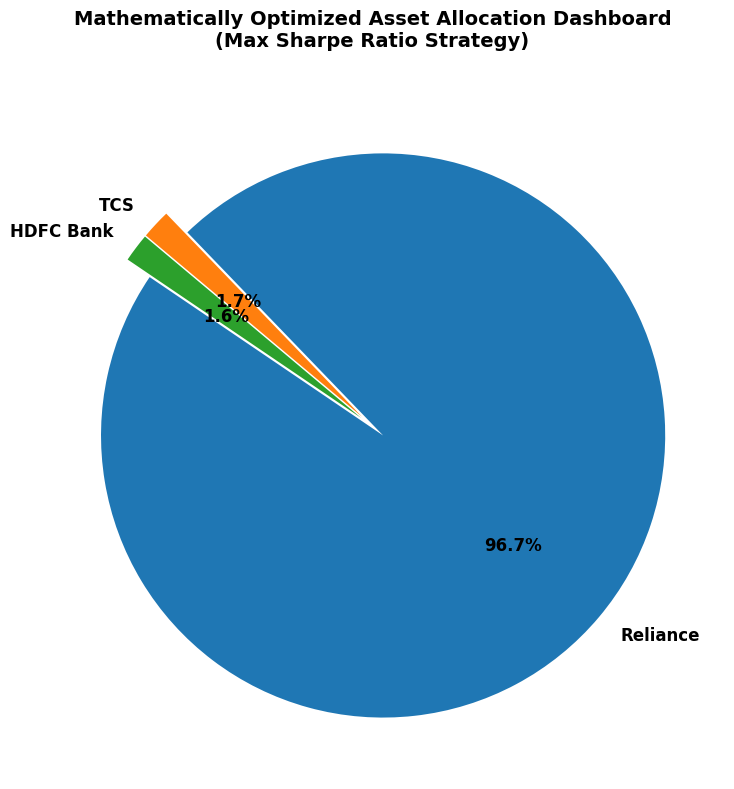

Optimized Weight for HDFC Bank: 1.62%
Optimized Weight for Reliance: 96.69%
Optimized Weight for TCS: 1.68%


In [7]:
# Pillar 4: Real Sharpe Ratio Optimization (Modern Portfolio Theory)
import numpy as np
import matplotlib.pyplot as plt

# 1. Annualized Returns aur Covariance Matrix calculate karna
annual_returns = port_returns.mean() * 252
cov_matrix = port_returns.cov() * 252

# 2. Optimization Logic (Monte Carlo Simulation to find Best Weights)
num_portfolios = 5000
results = np.zeros((3, num_portfolios))
weights_record = []

for i in range(num_portfolios):
    # Random weights generate karna jinka sum 1 (100%) ho
    w = np.random.random(3)
    w /= np.sum(w)
    weights_record.append(w)

    # Portfolio Return aur Risk (Standard Deviation) nikalna
    p_return = np.sum(w * annual_returns)
    p_std = np.sqrt(np.dot(w.T, np.dot(cov_matrix, w)))

    # Results store karna (Index 2 par Sharpe Ratio hai, Assuming Risk-Free Rate = 6%)
    results[0,i] = p_return
    results[1,i] = p_std
    results[2,i] = (p_return - 0.06) / p_std

# Max Sharpe Ratio wale weights nikalna
max_sharpe_idx = np.argmax(results[2])
optimized_weights = weights_record[max_sharpe_idx] * 100

# 3. Real Optimized Pie Chart Dashboard
labels = ['HDFC Bank', 'Reliance', 'TCS']
colors = ['#2ca02c', '#1f77b4', '#ff7f0e']

plt.figure(figsize=(8, 8))
plt.pie(optimized_weights, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors,
        textprops={'fontsize': 12, 'fontweight': 'bold'}, explode=(0.05, 0.05, 0.05))

plt.title('Mathematically Optimized Asset Allocation Dashboard\n(Max Sharpe Ratio Strategy)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Values print karke check karne ke liye
for stock, weight in zip(labels, optimized_weights):
    print(f"Optimized Weight for {stock}: {weight:.2f}%")


**Financial Insights: Modern Portfolio Theory & Asset Allocation**

**Diversification Logic: **To mitigate idiosyncratic (asset-specific) risk, the model constructs a multi-asset framework analyzing three heavyweights: Reliance, TCS, and HDFC Bank through an annualized covariance matrix.

**Sharpe Ratio Maximization:** Utilizing a Monte Carlo Simulation across 5,000 randomized asset allocations, the quantitative algorithm solves for the optimal portfolio weight that yields the highest return per unit of risk. The mathematical optimization heavily prioritizes the highest risk-adjusted asset based on its superior historical Sharpe performance over the trailing 5-year cycle.

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  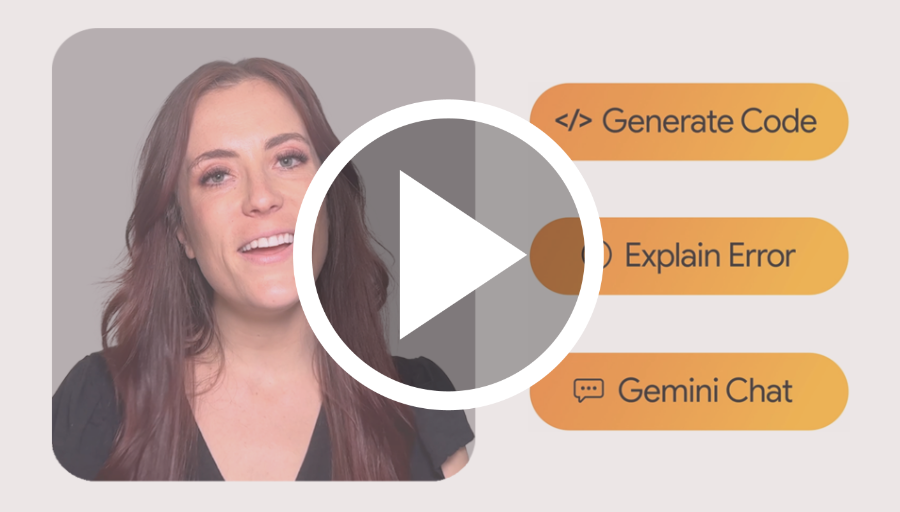
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

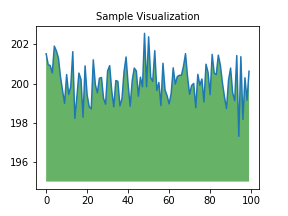

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
